# Vertebral Column dataset


In [5]:
## Importing
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
from evclust.utils import plotting, display_results_fuzzy_partition, display_results_evidential
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from ucimlrepo import fetch_ucirepo

from evclust.ecm import ecm
from evclust.wecm_new_barycenter import wecm
from evclust.wecm_new_barycenter_2 import wecm as wecm2
from evclust.fcm.fcm_keller2000 import fcm as fcm_keller2000
from evclust.fcm.fcm_wang2004 import fcm as fcm_wang2004
from evclust.fcm.fcm_frigui2004 import scad1
from evclust.fcm.fcm_frigui2004 import scad2
from evclust.fcm.ifwfcm_xing2014 import fcm as ifwfcm_xing2014
from evclust.fcm.ifwfcm_kd_xing2014 import fcm as ifwfcm_kd_xing2014

Instances 310 - Features 6 - Class 3
   pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
0         63.027817    22.552586              39.609117     40.475232   
1         39.056951    10.060991              25.015378     28.995960   
2         68.832021    22.218482              50.092194     46.613539   
3         69.297008    24.652878              44.311238     44.644130   
4         49.712859     9.652075              28.317406     40.060784   

   pelvic_radius  degree_spondylolisthesis  
0      98.672917                 -0.254400  
1     114.405425                  4.564259  
2     105.985135                 -3.530317  
3     101.868495                 11.211523  
4     108.168725                  7.918501  


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


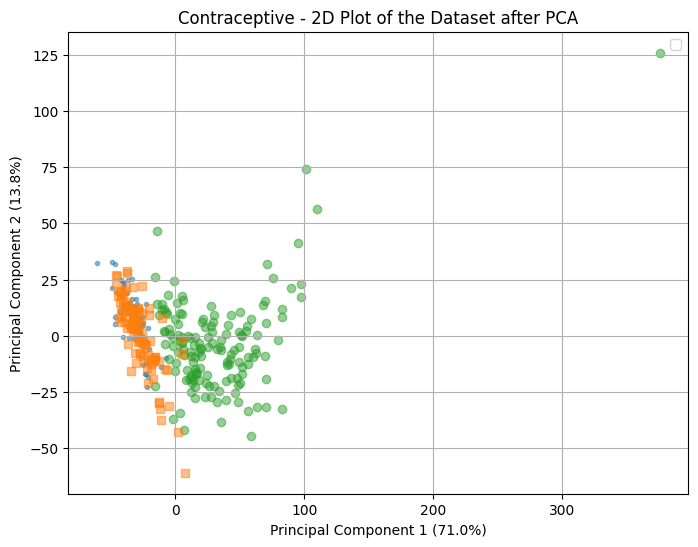

In [6]:

# fetch dataset
df = fetch_ucirepo(id=212)
X = df.data.features
y = df.data.targets

label_column_nm = y.columns[0]
labels_encoder = LabelEncoder()
numeric_labels = labels_encoder.fit_transform(y[label_column_nm])
plotting(X, y, ds_name="Contraceptive", matrix_plot=False)
c = len(np.unique(numeric_labels))

# Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(scaler.fit_transform(X))

## Traditional ECM

In [7]:
%%capture
# Traditional ECM clustering
delta = np.sqrt(20)
ecm_models = np.array([])
for i in range(10):
    model = ecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", epsi=1e-5)
    ecm_models = np.append(ecm_models, model)

ecm_models = sorted(ecm_models, key=lambda x: x['crit'])

J values: [6.942017395690516, 6.942018392348616, 6.942018451260935, 6.942019540832508, 6.94202065525868, 6.942021196535418, 6.942021404715937, 6.942028315076157, 6.9420312916790285, 6.942032283225823]
ARI values: [0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.2051593038434538, 0.20788758466254018, 0.20788758466254018, 0.20788758466254018]
NS values: [1.4494570224739307, 1.514301686868389, 1.5143788949767625, 1.449369042197871, 1.4186134815204507, 1.418810996388339, 1.3826737300221246, 1.4188153151782517, 1.5147748215416477, 1.381867006281237]
NMI values: [0.2504571304327827, 0.2504571304327828, 0.2504571304327828, 0.2504571304327827, 0.2504571304327828, 0.2504571304327828, 0.2504571304327828, 0.25284978437442507, 0.252849784374425, 0.25284978437442507]


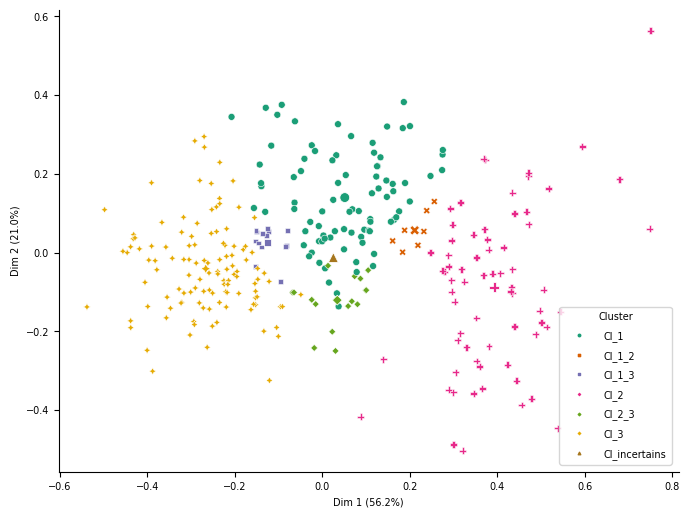

In [8]:
display_results_evidential(X, ecm_models, numeric_labels, up_low_appr=False)

## Weighted ECM (WECM)

In [9]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = wecm(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center")
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.07533642176842255, 0.07533642176842262, 0.07533642176842278, 0.07533642176842281, 0.07533642176842284, 0.07534167499997949, 0.07534167499997965, 0.07534167499997972, 0.07534167499997972, 0.07535553406592002]
ARI values: [0.4242367989424496, 0.4242367989424496, 0.4242367989424496, 0.4242367989424496, 0.4242367989424496, 0.4242367989424496, 0.4242367989424496, 0.4242367989424496, 0.4242367989424496, 0.4219497621461128]
NS values: [0.6916711042795596, 0.7580678267763395, 0.9668136719529662, 1.168970286316123, 1.1646500299694933, 1.0271861920855334, 0.6899648953921729, 1.166693939764473, 1.166693939764473, 0.7555739511243803]
NMI values: [0.5557956942104454, 0.5557956942104455, 0.5557956942104454, 0.5557956942104455, 0.5557956942104455, 0.5557956942104455, 0.5557956942104454, 0.5557956942104455, 0.5557956942104455, 0.5552335562778148]


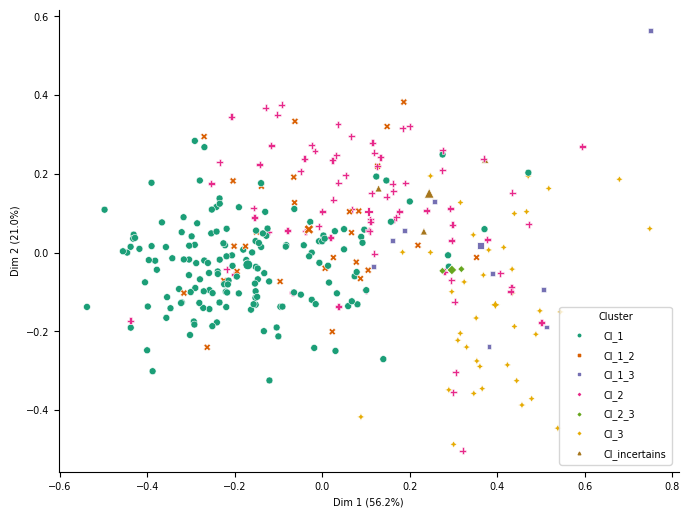

In [10]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

## WECM2

In [11]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None", epsilon=1e-4)
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.13962979172962842, 0.13963085983252194, 0.13963111608387507, 0.13963169696582506, 0.13963181209913114, 0.13963398055826226, 0.13963468319787556, 0.13963533733326913, 0.13972915479168996, 0.14023577569078294]
ARI values: [0.20412136064700703, 0.20412136064700703, 0.20412136064700703, 0.20412136064700703, 0.20412136064700703, 0.20412136064700703, 0.20412136064700703, 0.20412136064700703, 0.20412136064700703, 0.19836468508194707]
NS values: [1.240644472532041, 1.210916093866145, 1.0558668948212955, 1.328841089721475, 1.3288401599318185, 1.3289417538498807, 1.3290071973003204, 1.3448809495777603, 1.244346350556966, 1.2283351814957846]
NMI values: [0.28412866243374235, 0.2841286624337424, 0.2841286624337424, 0.2841286624337424, 0.2841286624337424, 0.2841286624337424, 0.2841286624337424, 0.2841286624337424, 0.28412866243374235, 0.28556564793613787]


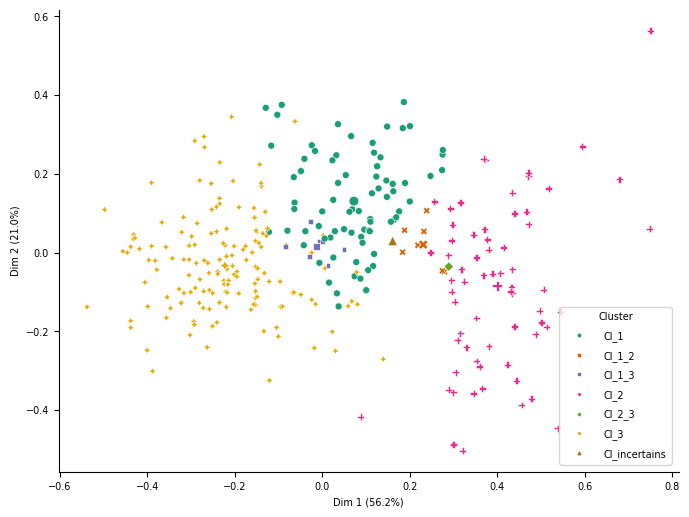

In [12]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

# Weighted FCM - Keller et al. 2000

In [13]:
%%capture
keller_models = np.array([])
w0 = np.ones((c, X.shape[1])) / X.shape[1]
for i in range(10):
    model = fcm_keller2000(X, c=c, w0=w0, verbose=True, epsilon=1e-6)
    keller_models = np.append(keller_models, model)
keller_models = sorted(keller_models, key=lambda model: model['obj_func'])

J values: [0.15989542300873455, 0.15989542300873455, 0.1598954371949571, 0.1598954371949571, 0.1598954371949571, 0.1598954371949571, 0.15989543719495714, 0.15989543719495714, 0.15989543719495714, 0.15989543719495716]
ARI values: [0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859, 0.4738905267444859]
NMI values: [0.5693200024134045, 0.5693200024134045, 0.5693200024134045, 0.5693200024134045, 0.5693200024134045, 0.5693200024134045, 0.5693200024134044, 0.5693200024134044, 0.5693200024134044, 0.5693200024134045]


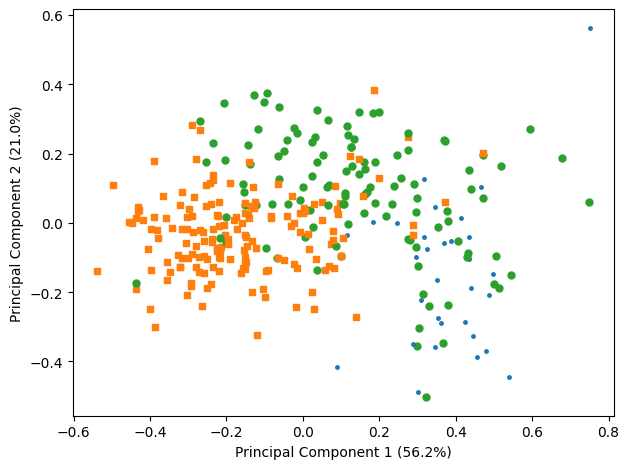

In [14]:
display_results_fuzzy_partition(X, keller_models, numeric_labels)

# Weighted FCM Wang 2004

In [15]:
%%capture
wang_models = np.array([])
for i in range(2):
    model = fcm_wang2004(X, c, w_beta=2.4, verbose=True)
    wang_models = np.append(wang_models, model)
wang_models = sorted(wang_models, key=lambda model: model['obj_func'])

J values: [0.3171220427944967, 0.3171220427944967]
ARI values: [0.21710253825862197, 0.21710253825862197]
NMI values: [0.2759028519729139, 0.2759028519729139]


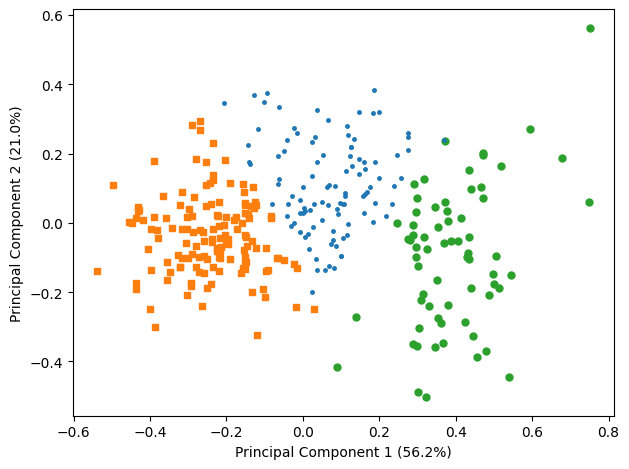

In [16]:
display_results_fuzzy_partition(X, wang_models, numeric_labels)

# SCAD1

In [17]:
%%capture
scad1_models = np.array([])
for i in range(10):
    model = scad1(X, c, verbose=True, K=2, epsilon=1e-6, init="None", stop_factor="Center")
    scad1_models = np.append(scad1_models, model)
scad1_models = sorted(scad1_models, key=lambda model: model['obj_func'])


J values: [5.338843030335681, 5.3388430481843905, 5.338843126648562, 5.338843191332813, 5.338843195932671, 5.338843248127497, 5.338843434736274, 5.338843453775446, 5.338843641287571, 5.3388436773120755]
ARI values: [0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125, 0.20738168094032125]
NMI values: [0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253, 0.26611039753744253]


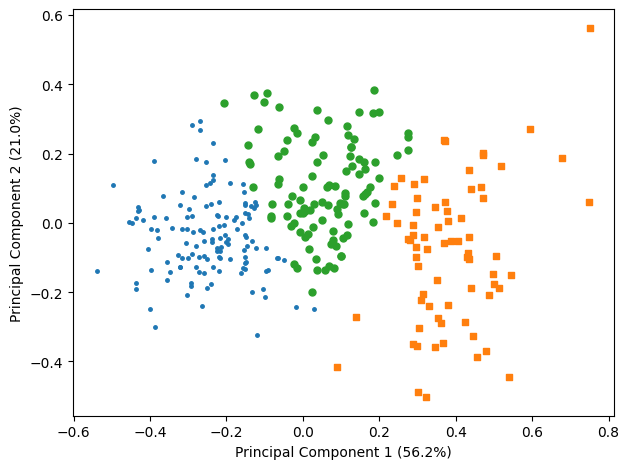

In [18]:
display_results_fuzzy_partition(X, scad1_models, numeric_labels)

# SCAD2

In [19]:
%%capture
scad2_models = np.array([])
for i in range(10):
    model = scad2(X, c, verbose=True, init="None", epsilon=1e-6, stop_factor="center")
    scad2_models = np.append(scad2_models, model)
scad2_models = sorted(scad2_models, key=lambda model: model['obj_func'])


J values: [0.22187538270206458, 0.22187547789274337, 0.22187548033146218, 0.22187548120620618, 0.22187548162295068, 0.2218754820119243, 0.22187548382914113, 0.22187548585904732, 0.22187548657967482, 0.22187549415337116]
ARI values: [0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967, 0.1806135396947967]
NMI values: [0.27174278120735235, 0.27174278120735235, 0.27174278120735235, 0.2717427812073524, 0.27174278120735235, 0.27174278120735235, 0.2717427812073524, 0.27174278120735235, 0.2717427812073524, 0.2717427812073524]


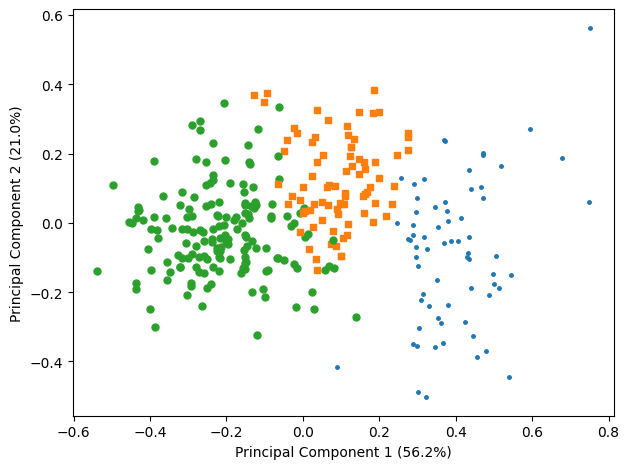

In [20]:
display_results_fuzzy_partition(X, scad2_models, numeric_labels)

# IFWFCM - Xing et al. 2014

In [21]:
%%capture
ifwfcm_models = np.array([])
for i in range(10):
    model = ifwfcm_xing2014(X, c, verbose=True)
    ifwfcm_models = np.append(ifwfcm_models, model)
ifwfcm_models = sorted(ifwfcm_models, key=lambda model: model['obj_func'])

J values: [0.24031805546502943, 0.24031805546502946, 0.24031805546502946, 0.2403180554650295, 0.2403180554650295, 0.2403193344198525, 0.24031933441985254, 0.24031933441985254, 0.24031933441985268, 0.24031933441985268]
ARI values: [0.2504252811703434, 0.2504252811703434, 0.2504252811703434, 0.2504252811703434, 0.2504252811703434, 0.2504252811703434, 0.2504252811703434, 0.2504252811703434, 0.2504252811703434, 0.2504252811703434]
NMI values: [0.3465524886352417, 0.3465524886352417, 0.3465524886352417, 0.3465524886352417, 0.3465524886352417, 0.3465524886352417, 0.3465524886352417, 0.3465524886352417, 0.3465524886352417, 0.3465524886352417]


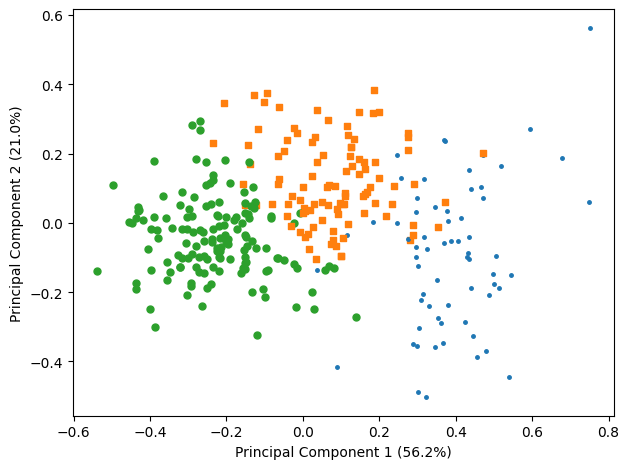

In [22]:
display_results_fuzzy_partition(X, ifwfcm_models, numeric_labels)

# IFWFCM_KD Xing 2014

In [23]:
%%capture
ifwfcm_kd_models = np.array([])
for i in range(10):
    model = ifwfcm_kd_xing2014(X, c, verbose=True, epsilon=1e-6)
    ifwfcm_kd_models = np.append(ifwfcm_kd_models, model)
ifwfcm_kd_models = sorted(ifwfcm_kd_models, key=lambda model: model['obj_func'])

J values: [4.52612166281293, 4.52612166281293, 4.52612166281293, 4.52612166281293, 4.52612166281293, 4.526121662812931, 4.526121701522252, 4.526121701522252, 4.526121701522252, 4.526121701522253]
ARI values: [0.37807656429779046, 0.37807656429779046, 0.37807656429779046, 0.37807656429779046, 0.37807656429779046, 0.37807656429779046, 0.37807656429779046, 0.37807656429779046, 0.37807656429779046, 0.37807656429779046]
NMI values: [0.48943137587253854, 0.48943137587253854, 0.48943137587253854, 0.48943137587253854, 0.48943137587253854, 0.48943137587253854, 0.48943137587253854, 0.48943137587253854, 0.48943137587253854, 0.48943137587253854]


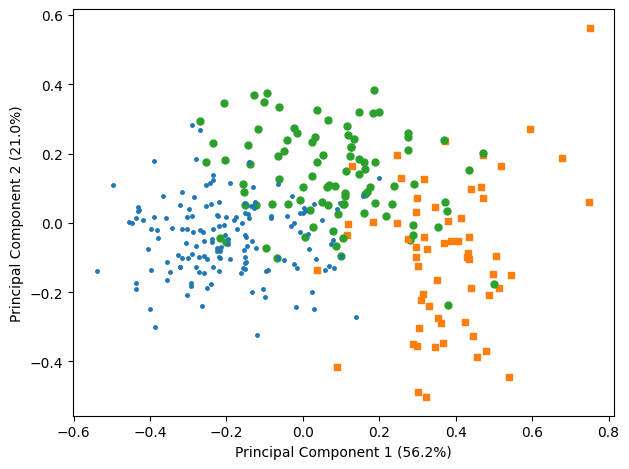

In [24]:
display_results_fuzzy_partition(X, ifwfcm_kd_models, numeric_labels)